In [11]:
import requests
import pandas as pd
import geopandas as geopd
from shapely import Point
import matplotlib.pyplot as plt
from tqdm import tqdm

plt.rcParams["figure.dpi"]  = 300
plt.style.use('dark_background')
pd.options.display.max_columns = 30
pd.options.display.min_rows = 20
pd.options.display.max_rows = 30

# This script downloads flow data from the SYKE API and processes it.
# It fetches measurement locations, retrieves flow data for each location,
# and saves the data as a Parquet file.

In [3]:
def dict_list_to_df(values):
     """
    Converts a list of dictionaries to a DataFrame.
    """
    df = pd.DataFrame(columns=list(values[0].keys()))
    for item in values:
        new = pd.DataFrame([item])
        df = pd.concat([df, new], ignore_index=True)
    return df

# Fetching the places where water level is being measured. This will be used to to query flow data later.

In [4]:
url = "https://rajapinnat.ymparisto.fi/api/Hydrologiarajapinta/1.1/odata/Paikka?$filter=Virtaama%2Fany(x%3A%20x%2FAika%20le%20datetime%272024-09-12T04%3A50%3A43.910Z%27)"

places = pd.DataFrame()
while True: # The length of data is unkown, so we continue until there is no more data.
    response = requests.get(url)
    
    if response.status_code == 200:
        content = response.json()
        keys = content.keys()
    else:
        print(f"Error with request from url {url}, error code {response.status_code}")
    
    values = content['value']
    places = pd.concat([places, dict_list_to_df(values)], ignore_index=True)
    
    # Is there still content left?
    if 'odata.nextLink' in keys:
        url = content['odata.nextLink']
    else:
        break

# Dictionary
## Skipping translation of some columns because they only relevant for Finnish base maps, or are mostly relevant to Finnish authorities

- Paikka_Id: place id
- Suure_Id: attribute id (2==Q, which should be all of the entries)
- H_Kunta_id: municipality id
- KuntaNimi: municipality name
- Nro: number of the gauge
- Nimi: Name of the gauge
- KoordLat: Latitude (epsg 4326)
- KoordLong: Longitude (epsg 4326)
- KoordErTmPohj: northing, ETRS-TM35FIN (epsg 3067)
- KoordErTmIta: easting, ETRS-TM35FIN (epsg 3067)
- Jarvi_Id: lake id (none if river)
- JarviNro: lake number (SYKE's hierachical classification) (none if river)
- JarviNimi: Name of the lake (none if river)

In [13]:
# Creating the geometry of the measurement locations using  ETRS-TM35 coordinates
places['geometry'] = geopd.points_from_xy(places.KoordErTmIta, places.KoordErTmPohj)
geoplaces = geopd.GeoDataFrame(places, geometry='geometry', crs="EPSG:3067")

<Axes: >

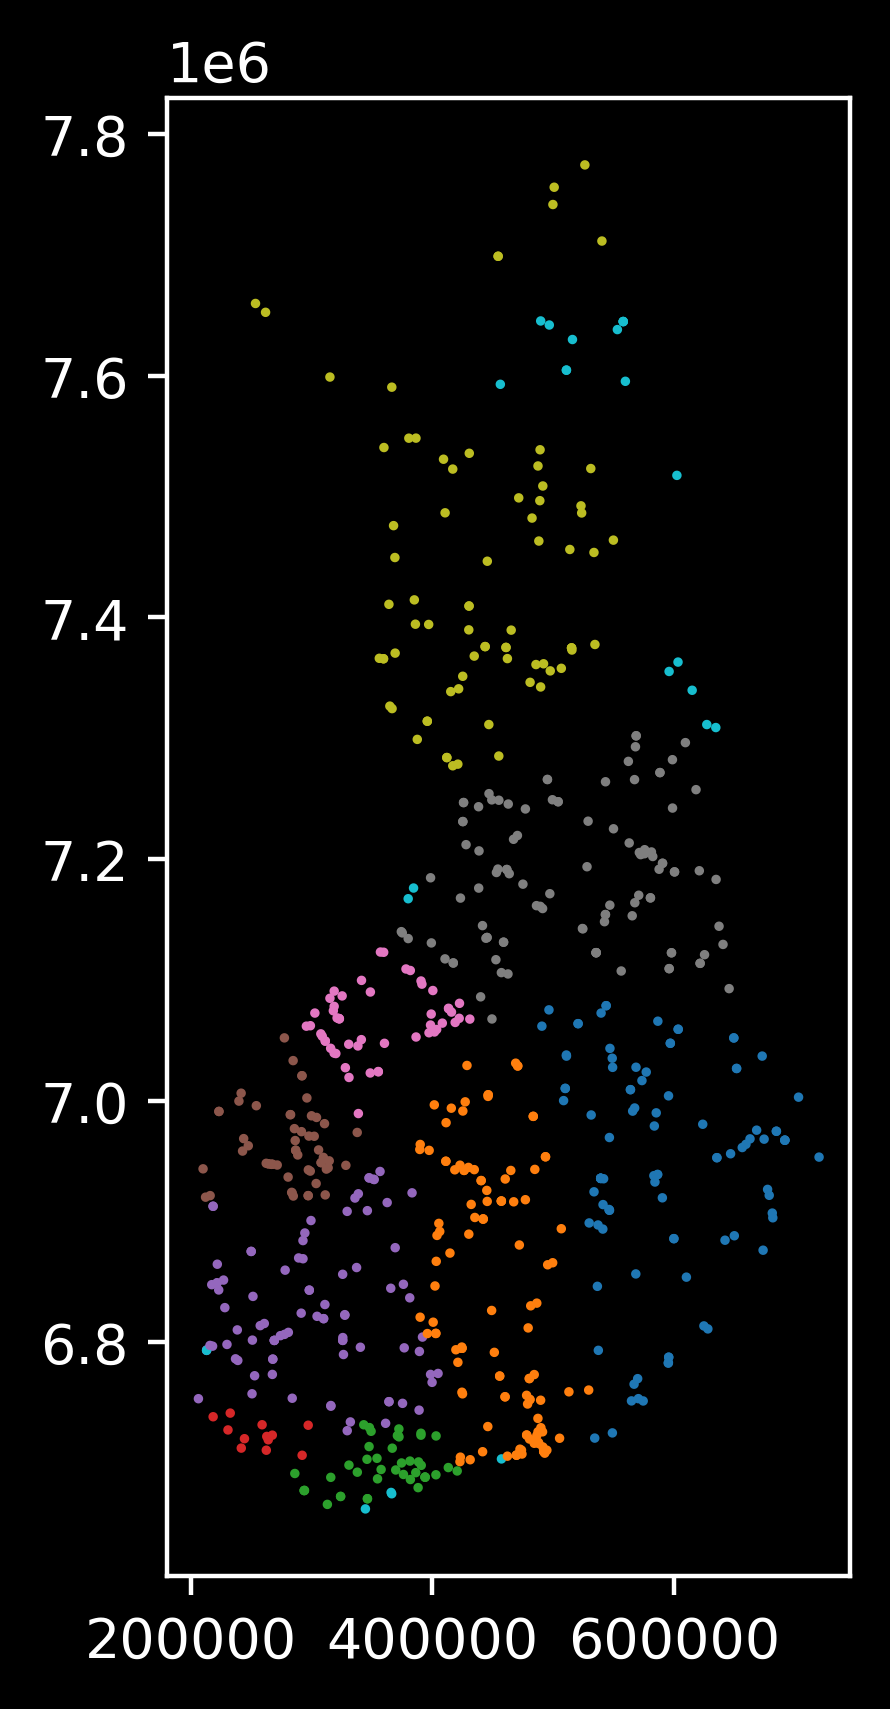

In [16]:
geoplaces.plot(column='H_PaaVesal_Id', markersize=0.5)

In [10]:
geoplaces.to_file('path/to/measurement_locations.gpkg', driver="GPKG", layer="all")

In [ ]:
paikka_ids = list(places.Paikka_Id)

flows = None
for place_id in tqdm(paikka_ids):
    flow_url = f"https://rajapinnat.ymparisto.fi/api/Hydrologiarajapinta/1.1/odata/Virtaama?$filter=Paikka/Paikka_Id%20eq%20{place_id}"
    place_flow = pd.DataFrame()
    
    while True:
        flow_batch = pd.DataFrame()
        try:
            response = requests.get(flow_url)
        except error as e:
            with open("error_log.txt", 'a') as error_log:
                error_log.write(f"Place {place_id}, error with request:{e}\n")
            break

        if response.status_code == 200:
            content = response.json()
            keys = content.keys()
        else:
            with open("error_log.txt", 'a') as error_log:
                error_log.write(f"Place {place_id}, error with status code {response.status_code}")
            break
          
        values = content['value']

        for i, value in enumerate(values):
            flow_batch.at[i, 'datetime'] = value['Aika'] # Aika == time
            flow_batch.at[i, str(place_id)] = float(value['Arvo']) # Arvo == value

        place_flow = pd.concat([place_flow, flow_batch], ignore_index=True)
        
        # Is there still content left?
        if 'odata.nextLink' in keys:
            flow_url = content['odata.nextLink']
        else:
            break
        
    place_flow = place_flow.set_index(pd.DatetimeIndex(place_flow['datetime']), drop=True)
    place_flow = place_flow.drop('datetime', axis=1)

    if flows is None:
        flows = place_flow
    else:
        flows = pd.merge(flows, place_flow, on='datetime', how='outer')

# Save the flow data to a Parquet file
dst_file_name = 'all_flows'
# uncomment the format you want. Parquet can handle datetime natively
flows.to_parquet(f"{dst_file_name}.parquet")
#flows_to_csv(f"{dst_file_name}.csv")

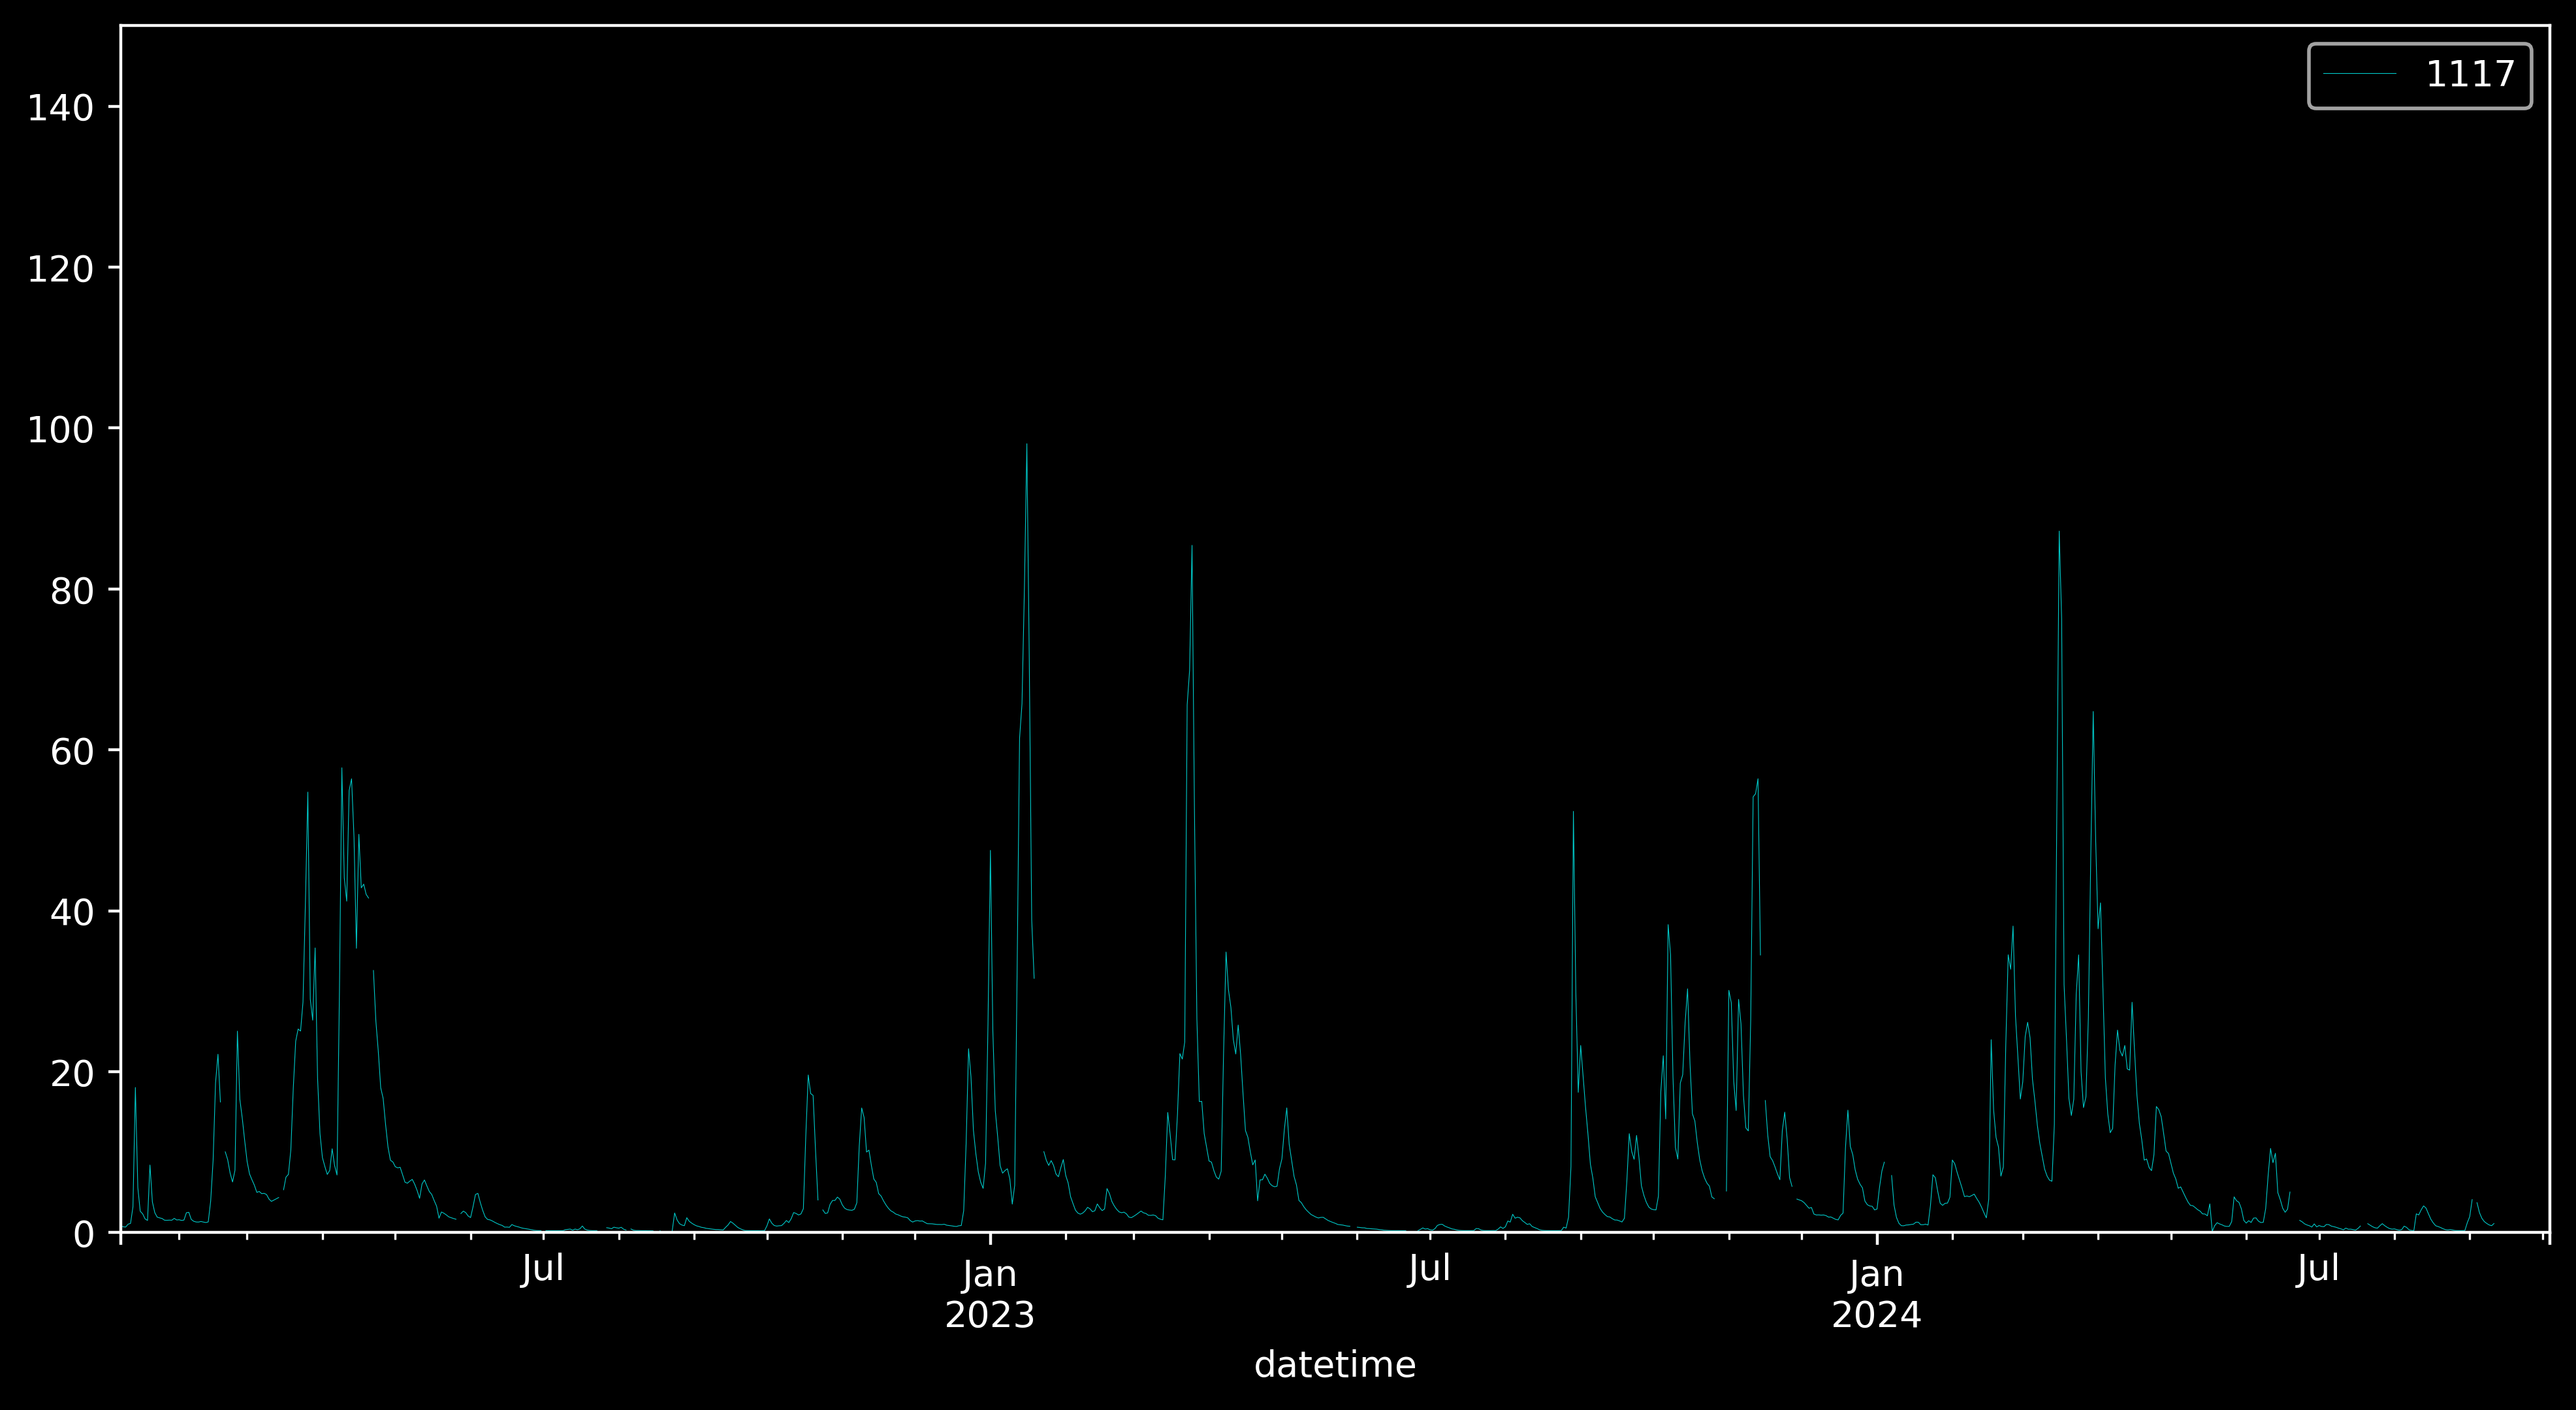

In [79]:
# Plot the flow data for a specific gauge (e.g., Aurajoki == 1117)
lines = flows[['1117']].plot.line(figsize=(12, 6), xlim=(19000,20000), ylim=(0, 150), cmap='cool', alpha=0.8, linewidth=0.2)